# ASSIGNMENT 1: PART 1

Analysis on Palmer Penguins Dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
penguins_df = sns.load_dataset('penguins')

In [3]:
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [4]:
penguins_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


> 1. Using the body_mass_g column from the Palmer Penguins dataset, demonstrate the effect of an outlier by adding an extreme value, compare the mean and median before and after the outlier, and write your observations based on the `results in your own words as comments.

In [5]:
mean_before_outlier = penguins_df['body_mass_g'].mean()
print(mean_before_outlier)

4201.754385964912


In [6]:
median_before_outlier = penguins_df['body_mass_g'].median()
print(median_before_outlier)

4050.0


In [7]:
penguins_df.dropna(inplace=True)

In [8]:
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [9]:
penguins_df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


In [10]:
outlier = {
    'species': 'Adelie',
    'island' : 'Torgersen',
    'bill_length_mm' : 37.5,
    'bill_depth_mm' : 1,
    'flipper_length_mm' : 181,
    'body_mass_g' : 9750,
    'sex' : 'Female'
}

In [11]:
body_mass = penguins_df['body_mass_g']

In [12]:
body_mass.dtype

dtype('float64')

In [13]:
body_mass

,body_mass_g
0,3750.0
1,3800.0
2,3250.0
4,3450.0
5,3650.0
...,...
338,4925.0
340,4850.0
341,5750.0
342,5200.0


In [14]:
body_mass_outlier = pd.concat([body_mass, pd.Series( 119750)], ignore_index=True)


In [15]:
body_mass_outlier

,0
0,3750.0
1,3800.0
2,3250.0
3,3450.0
4,3650.0
...,...
329,4850.0
330,5750.0
331,5200.0
332,5400.0


In [16]:
body_mass_outlier.describe()

,0
count,334.000000
mean,4552.994012
std,6373.146732
min,2700.000000
25%,3550.000000
50%,4050.000000
75%,4793.750000
max,119750.000000


In [17]:
mean_after_outlier = body_mass_outlier.mean()
print(mean_after_outlier)

4552.994011976048


In [18]:
median_after_outlier = body_mass_outlier.median()
print(median_after_outlier)

4050.0


## OBSERVATION

Adding a single large outlier changes the mean from 4201.7 to 4552.99 which means that mean is sensitive to outliers or anomalies as it is found by adding all the values and diving them by total numbebr of observations.

The median is a robust measure and it is not affwctwd by outliers as we can see here, it remains 4050. It denotes the central value of the data.

But why did it not change- there were 333 data points before the outlier and after adding the outlier it became 334 rows. Then shouldn't the positional value change? NO, it is not necessarily true, as the median position for 333 rows is 167th value, and for 334 rows, median would be a value between 167th and 168th value. Since it is a large dataset, there need not be much difference in the average value of the 167th and 165th value. That's why it did not change.



> 2. Using the flipper_length_mm column from the Palmer Penguins dataset, create
histograms to compare the distribution of flipper lengths across different penguin
species, and write your observations based on the visualization and results in your own
words as comments.




In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

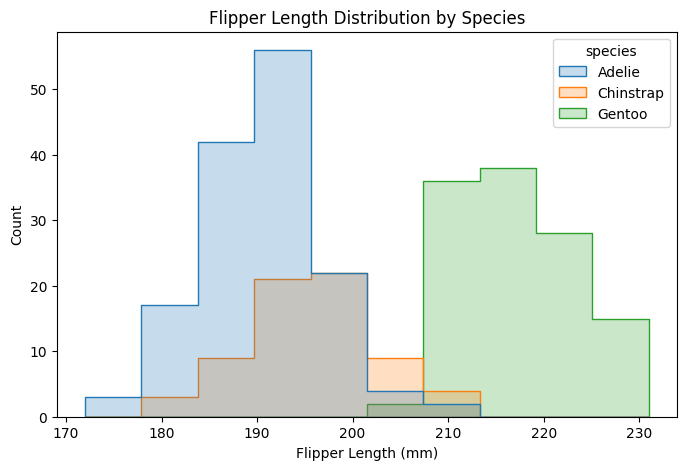

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(data=penguins_df, x="flipper_length_mm", hue="species", element="step", stat="count")
plt.title("Flipper Length Distribution by Species")
plt.xlabel("Flipper Length (mm)")
plt.show()

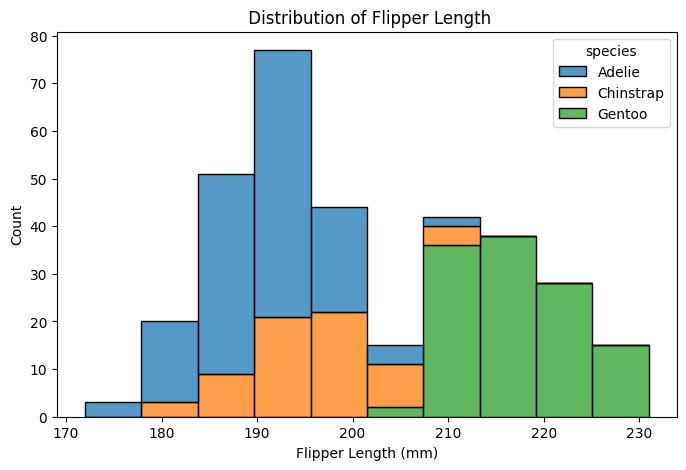

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(data=penguins_df, x="flipper_length_mm", hue="species", multiple="stack")
plt.title(" Distribution of Flipper Length")
plt.xlabel("Flipper Length (mm)")
plt.show()


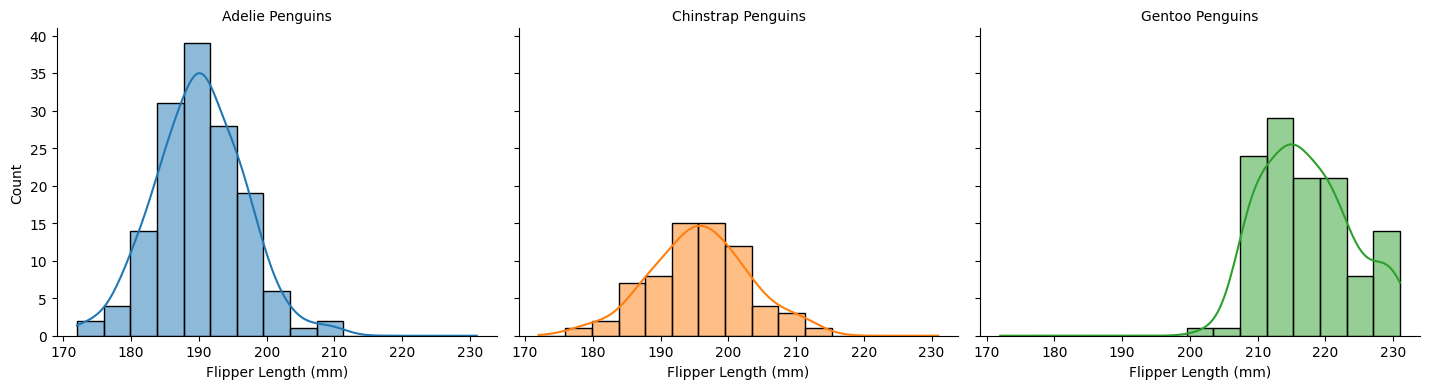

In [22]:
g = sns.displot(
    data=penguins_df,
    x="flipper_length_mm",
    col="species",     # Creates a separate subplot panel for each species
    hue="species",     # Colors each species differently
    kde=True,          # Adds a smooth probability density line
    bins=15,           # Keeps the intervals clean and clear
    height=4,
    aspect=1.2,
    legend=False
)

g.set_titles("{col_name} Penguins")
g.set_axis_labels("Flipper Length (mm)", "Count")

plt.show()


In [23]:
penguins_df['flipper_length_mm'].groupby(penguins_df['species']).describe()

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Adelie,146.0,190.102740,6.521825,172.0,186.0,190.0,195.0,210.0
Chinstrap,68.0,195.823529,7.131894,178.0,191.0,196.0,201.0,212.0
Gentoo,119.0,217.235294,6.585431,203.0,212.0,216.0,221.5,231.0


## OBSERVATIONS AND ANALYSIS



From the above histograms, we can see the representation of flipper_length across the 3 different species. We have 3 species namely Adelie(146 samples), Chinstrap(68 samples), and Gentoo(119 samples).

The above visualisation shows that Adelie has a mean flipper length of 190 mm. Chinstrap has mean length of 195 mm.  Most of the penguins from Adelie and Chinstrap have flipper lengths tightly clustered between 180 mm to 200 mm.

While Gentoo shows an exception with the lengths ranging from 203 mm to 231 mm and the mean being 217 mm. Their flippers are significantly larger than the other two species.

All the species' flipper lengths follow a fairly normal distribution as shown by the bell shaped curve.

> 3. Using the body_mass_g column from the Palmer Penguins dataset, compare the
distribution of body mass across different penguin species by calculating the variance,
skewness, kurtosis, and Pearson's coefficients of skewness, and write your observations
based on the results in your own words as comments.

In [24]:
def calculate_distribution(data):
    mean = np.mean(data)
    median = np.median(data)
    var = np.var(data)
    std_dev = np.std(data)

    skw = data.skew()
    kurt = data.kurtosis()

    # Pearson's Second Coefficient of Skewness (Median-based formulation)
    # Formula: 3 * (Mean - Median) / Standard Deviation
    pearson_skew = 3 * (mean - median) / std_dev

    return pd.Series({
        "Mean": mean,
        "Median": median,
        "Variance": var,
        "Standard Deviation": std_dev,
        "Skewness": skw,
        "Kurtosis": kurt,
        "Pearson skewness": pearson_skew
    })


metrics_df = (penguins_df.groupby("species")["body_mass_g"].apply(calculate_distribution).unstack())

print(metrics_df)

                  Mean  Median       Variance  Standard Deviation  Skewness  \
species                                                                       
Adelie     3706.164384  3700.0  208891.794896          457.046819  0.279892   
Chinstrap  3733.088235  3700.0  145541.198097          381.498621  0.247433   
Gentoo     5092.436975  5050.0  249365.069557          499.364666  0.045573   

           Kurtosis  Pearson skewness  
species                                
Adelie    -0.566935          0.040462  
Chinstrap  0.593379          0.260197  
Gentoo    -0.737787          0.254946  


# INTERPRETATION

#### **Variance**
###### Adelie (~ 208,892) and Gentoo (~ 145,541) penguins show higher variances in their weight as compared to Chinstrap (~ 145,541) penguins. This tells us that Chinstraps are uniform in weight, while Gentoo and Adelie sizes vary wildly from one another.

###### This means if we walk into a beach of penguins, the chinstraps might all look similar sized and weighed. But adelies and gentoos might have have different sizes and weights when compared with other adelies and gentoos.

#### **Skewness and Kurtosis**

###### The positive skewness coefficients reveal a slight right-side tail.  This indicates a few extra-heavy individual penguins pull the mean slightly higher than the median weight for those groups.

The negative excess kurtosis values show that the distributions are slightly flatter than a perfect normal distribution. This reflects a stable spread around the center without heavy outliers.

> 4. Using the body_mass_g column from the Palmer Penguins dataset, calculate the five- number summary (minimum, Q1, median, Q3, and maximum), determine the interquartile range (IQR), create grouped boxplots for each penguin species, and write your observations based on the visualization and results in your own words as comments.

In [25]:
def summary_iqr(data):
    summary = data.describe()
    q1 = summary["25%"]
    q3 = summary["75%"]
    iqr = q3 - q1

    return pd.Series({
        "minimum": summary["min"],
        "Q1": q1,
        "median": summary["50%"],
        "Q3": q3,
        "maximum": summary["max"],
        "IQR": iqr
    })

grouped_stats = (penguins_df.groupby("species")["body_mass_g"].apply(summary_iqr).unstack())

print(grouped_stats.to_string())

           minimum      Q1  median      Q3  maximum    IQR
species                                                   
Adelie      2850.0  3362.5  3700.0  4000.0   4775.0  637.5
Chinstrap   2700.0  3487.5  3700.0  3950.0   4800.0  462.5
Gentoo      3950.0  4700.0  5050.0  5500.0   6300.0  800.0


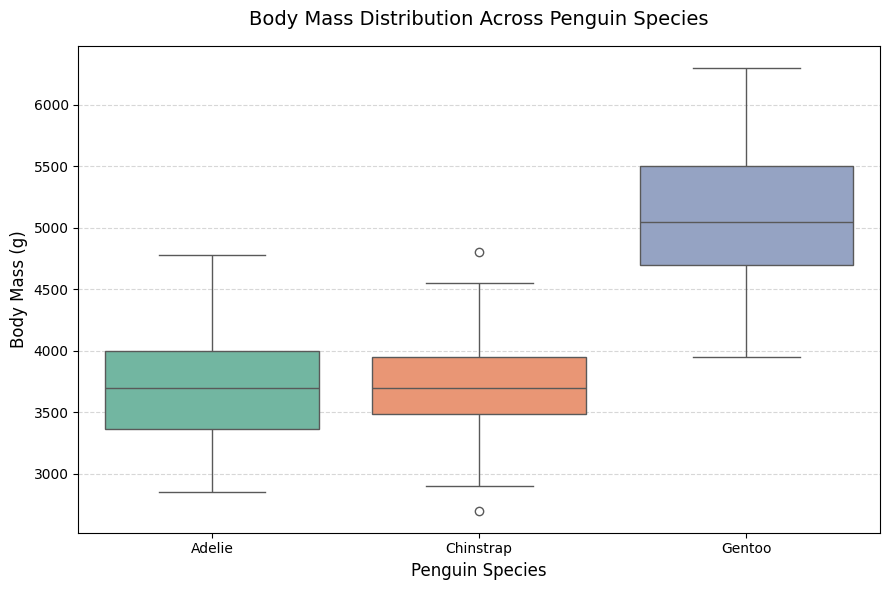

In [26]:
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=penguins_df,
    x="species",
    y="body_mass_g",
    hue="species",
    palette="Set2",
    legend=False
)
plt.title("Body Mass Distribution Across Penguin Species", fontsize=14, pad=15)
plt.xlabel("Penguin Species", fontsize=12)
plt.ylabel("Body Mass (g)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ANALYSIS

##### The boxes for Adelie and Chinstrap are almost perfectly level with each other. They share the same weight range, making them physical peers.

But on the other hand, Gentoo;s box sits high and starts roughly from where the other two end. This shows that gentoos are naturally heavier than other two species.

##### **The height of the box represents Interquartile Range (IQR).**

Gentoos' box is bigger than the other two which are short and squashed. That is, among average Gentoos, there is a wide range of body types. There is no single standard weight for a Gentoo, they naturally vary a lot unlike the others which are uniformly distributed.

In [27]:
covariance = penguins_df["flipper_length_mm"].cov(penguins_df["body_mass_g"])
correlation = penguins_df["flipper_length_mm"].corr(penguins_df["body_mass_g"])

print(f"Covariance between flipper length and body mass: {covariance}")
print(f"Correlation between flipper length and body mass: {correlation}")

Covariance between flipper length and body mass: 9852.191649480803
Correlation between flipper length and body mass: 0.872978898565361


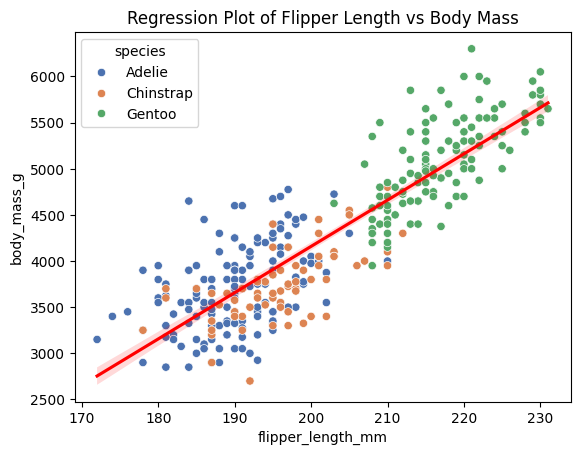

In [33]:
sns.scatterplot(
    data=penguins_df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    palette="deep"
)

sns.regplot(
    data=penguins_df,
    x="flipper_length_mm",
    y="body_mass_g",
    scatter=False,
    color="red"
)

plt.title("Regression Plot of Flipper Length vs Body Mass")
plt.show()

# OBSERVATION

1. The correlation between flipper length and body mass is around 0.87 which shows a strong positive linear relationship.So, this means that flipper length is a strong predictor of body mass, as larger individuals tend to have both longer flippers and greater mass.

2. Another interesting observation is that there are multiple dots stacked at certain flipper lengths like ~187mm, 190mm, 210mm. These suggest that the measured flipper lengths must have been rounded off to these values, i.e, the nearest whole mm.

3. There is a dense cluster of smaller penguins towards the lower left side and another cluster of larger penguins on the upper right side. This shows the distribution of the 3 species coloured in 3 different colours.

> 6. Using the body_mass_g column from the Palmer Penguins dataset, group the data based
on the island column and calculate the total penguin biomass supported by each island.
Create a pie chart to show the proportion of total biomass contributed by each island
and a bar chart to compare the absolute total biomass values. Write your observations
based on the visualization and results in your own words as comments.

In [34]:
biomass_by_island = penguins_df.groupby('island')['body_mass_g'].sum()

In [35]:
biomass_by_island

,body_mass_g
island,
Biscoe,769225.0
Dream,457425.0
Torgersen,174300.0


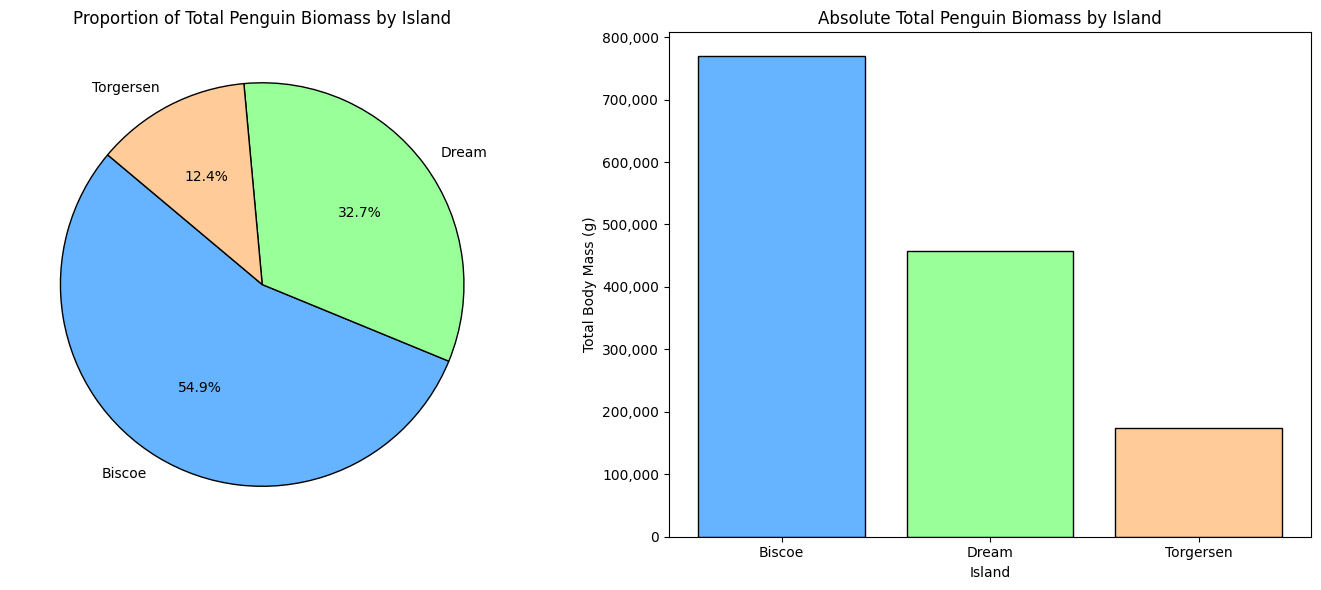

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#66b3ff', '#99ff99', '#ffcc99']

axes[0].pie(
    biomass_by_island,
    labels=biomass_by_island.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)
axes[0].set_title('Proportion of Total Penguin Biomass by Island')

axes[1].bar(
    biomass_by_island.index,
    biomass_by_island.values,
    color=colors,
    edgecolor='black'
)
axes[1].set_title('Absolute Total Penguin Biomass by Island')
axes[1].set_ylabel('Total Body Mass (g)')
axes[1].set_xlabel('Island')

# Format the y-axis with commas for readability (e.g., 800,000 instead of 800000)
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

# OBSERVATION

1. Biscoe island supports the vast majority of the total penguin biomass. Biologically, this makes sense because Biscoe is the only island in this dataset that hosts Gentoo penguins. Gentoos are significantly heavier than both Adelie and Chinstrap penguins, and they have a large population here.

2. Torgersen Island has the smallest slice of the pie. It exclusively hosts Adelie penguins, and the overall population count on this island is smaller compared to  the others.

3. Dream Island sits in the middle. Even though it hosts a very large number of birds (both Chinstrap and Adelie penguins), these species are significantly lighter than the Gentoos on Biscoe. Therefore, high population numbers do not automatically equate to the highest total biomass.


> 7. Using the bill_length_mm and bill_depth_mm columns from the Palmer Penguins
dataset, investigate whether the relationship between bill length and bill depth varies
across different penguin species. Create a scatter plot with different colors representing
each species to identify species-specific patterns and relationships. Write your
observations based on the visualization and results in your own words as comments.

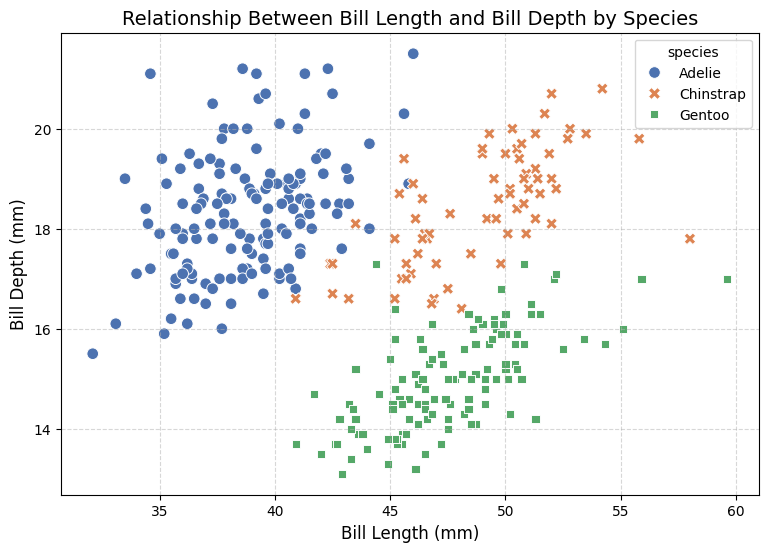

In [39]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=penguins_df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="species",
    palette="deep",
    s=70
)

plt.title("Relationship Between Bill Length and Bill Depth by Species", fontsize=14)
plt.xlabel("Bill Length (mm)", fontsize=12)
plt.ylabel("Bill Depth (mm)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

# OBSERVATION

1. Adelies have short but deep bills.
2. Chinstraps have long and deep bills.
3. Gentoos have long but shallow bills.
4. Aggregating the entire dataset suggests a negative relationship where
      longer bills look shallower.
  
   Grouping by species flips this completely to a positive relationship, proving that ignoring sub-categories masks true data trends.

# PART – 2 Analysis on Dow Jones Time-Series Dataset


In [40]:
import seaborn as sns
dowj_df = sns.load_dataset('dowjones')

In [41]:
dowj_df

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45
...,...,...
644,1968-08-01,883.72
645,1968-09-01,922.80
646,1968-10-01,955.47
647,1968-11-01,964.12


> 1. Using the Price column from the Dow Jones dataset, calculate the five-number
summary (minimum, Q1, median, Q3, and maximum) and determine the interquartile
range (IQR). Group the data using the engineered Decade column and create boxplots
to compare the distribution, spread, and median price values across different decades.
Write your observations

In [42]:
dowj_df.describe()

,Date,Price
count,649,649.000000
mean,1941-11-30 17:42:48.258859776,290.807319
min,1914-12-01 00:00:00,46.850000
25%,1928-06-01 00:00:00,106.900000
50%,1941-12-01 00:00:00,172.270000
75%,1955-06-01 00:00:00,436.730000
max,1968-12-01 00:00:00,985.930000
std,NaN,256.062906


In [43]:
summary_iqr(dowj_df["Price"])

,0
minimum,46.85
Q1,106.90
median,172.27
Q3,436.73
maximum,985.93
IQR,329.83


In [45]:
import seaborn as sns

In [48]:
dowj_df["Date"] = pd.to_datetime(dowj_df["Date"])
dowj_df["Decade"] = (dowj_df["Date"].dt.year // 10) * 10

/tmp/ipykernel_1942/1773063630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


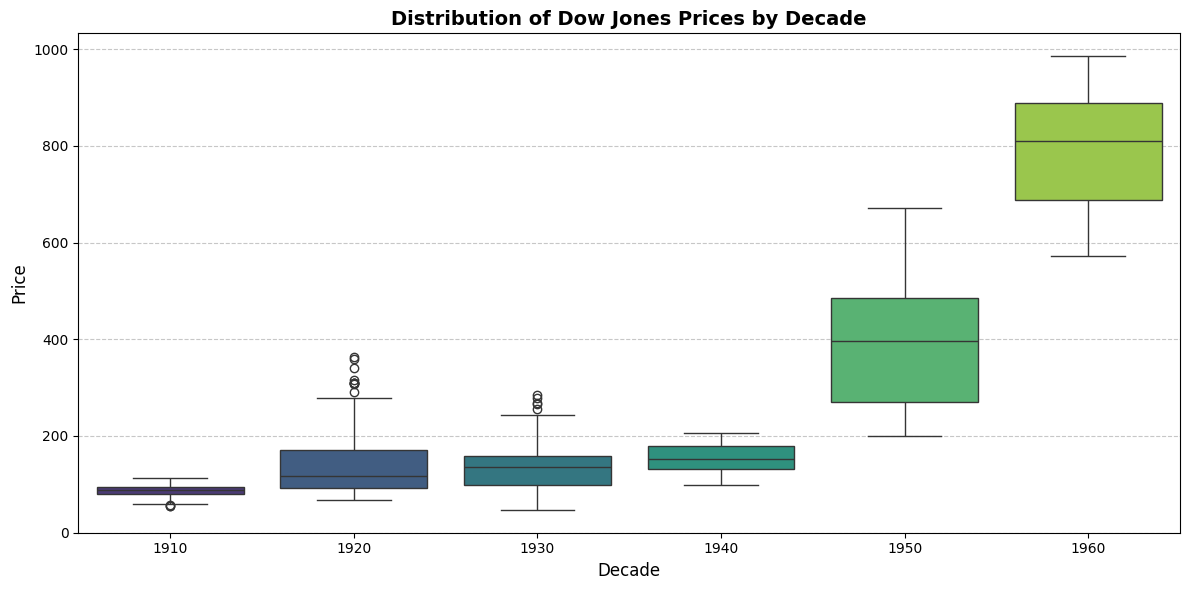

In [49]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=dowj_df,
    x='Decade',
    y='Price',
    palette='viridis'
)
plt.title('Distribution of Dow Jones Prices by Decade', fontsize=14, fontweight='bold')
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# OBSERVATION

1. The median lines are increasing from left to right. That represents the significant growth historically in the stock market prices.

2. By the 1950s and 1960s, there is an explosive upward shift. The median price in the 1960s jumps to roughly 800 from last decade's 400, which is 2 times of it.

3. A short box means prices stayed within a very tight, narrow range for most of those ten years. But during 1950 and 1960, the boxes and whiskers stretch across hundreds of points. As the overall value of the stock market grew, the absolute size of the price swings (the market's spread) grew drastically as well.

4. There are several bubbles over 1920 box showing outliers that are reaching 400. This shows the historical economic boom period when everone was buying shares and the prices reached the sky.

5. After the boom, the market faced a huge crash in 1929, which led to the wipe out of fortunes. Then creeped in the Great Depression in 1930. The outliers in the 1930s represent temporary price spikes. These dots show the violent, desperate bounce-backs of a market trying to recover in a deeply unstable economic environment.

> 2. Using the Date and Price columns from the Dow Jones dataset, create a time-series line
plot to visualize the change in index prices over time. Convert dates into numerical
values and fit a linear regression model to identify the overall trend in the data. Display
the regression trendline along with the original time-series data, calculate the Pearson
correlation coefficient and R-squared value, and write your observations based on the
visualization and results in your own words as comments.

In [50]:
from scipy.stats import linregress
import matplotlib.dates as mdates

In [51]:
numerical_dates = dowj_df['Date'].map(pd.Timestamp.toordinal)
prices = dowj_df['Price']

slope, intercept, r_value, p_value, std_err = linregress(numerical_dates, prices)

r_squared = r_value ** 2

# Generate the trendline values using the formula: y = mx + b
trendline = (slope * numerical_dates) + intercept

print("--- Statistical Metrics ---")
print(f"Pearson Correlation Coefficient (r): {r_value:.4f}")
print(f"R-squared Value: {r_squared:.4f}\n")

--- Statistical Metrics ---
Pearson Correlation Coefficient (r): 0.8264
R-squared Value: 0.6829



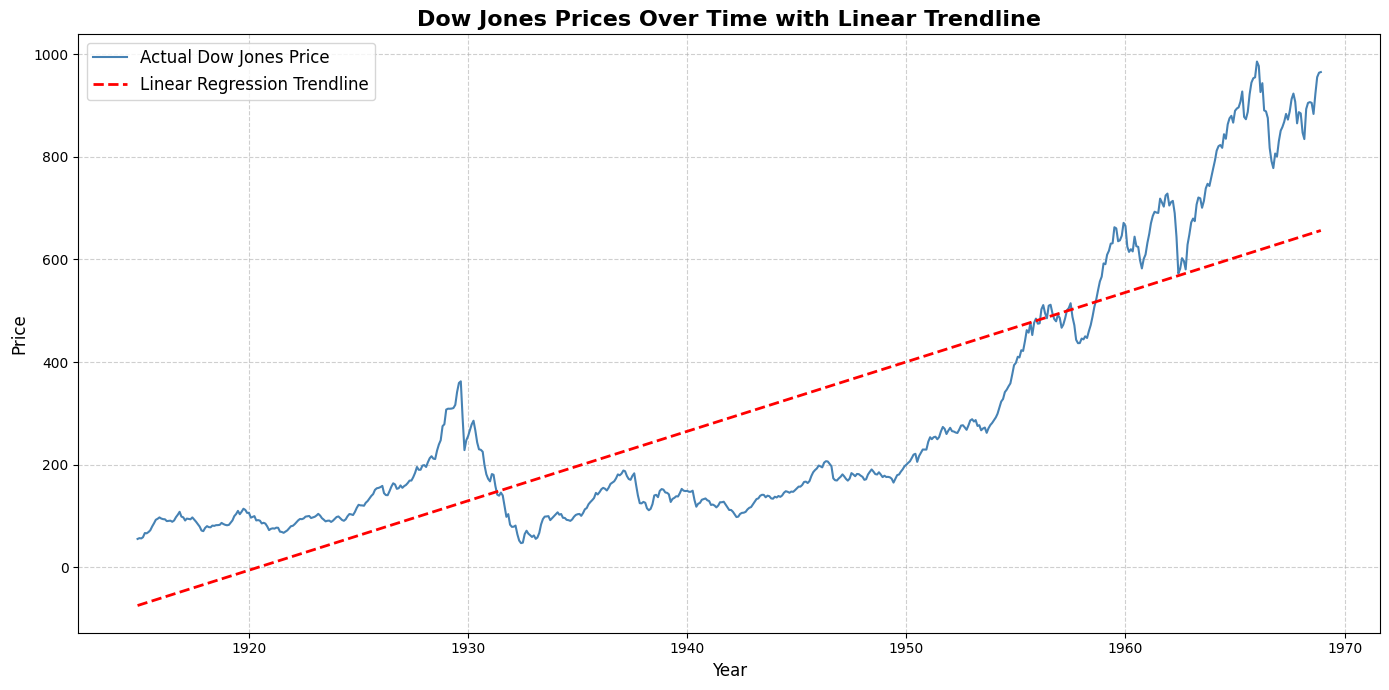

In [53]:
plt.figure(figsize=(14, 7))

plt.plot(dowj_df['Date'], prices, label='Actual Dow Jones Price', color='steelblue', linewidth=1.5)

plt.plot(dowj_df['Date'], trendline, label='Linear Regression Trendline', color='red', linewidth=2, linestyle='--')

plt.title('Dow Jones Prices Over Time with Linear Trendline', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#OBSERVATION

1. The correlation coefficient at 0.82 shows a positive long-term linear trend over the years.
2. But the Dow Jones price line, as we can see, grows until 1929, when the crash actually happens eventually after which the devastating plunge during the Great Depression occurs.
3. The line start climbing upwards after 1950 and finally pushes the index towards 1000 by the end of 1960s.
4. The limitation of linear regression for financial data:
    - The red dashed line actually drops below zero. A stock market index cannot have a negative price. This happens because the algorithm is just drawing a rigid, straight line based on the massive growth later in the century, dragging the starting point down too far.

    - Linear regression assumes that the market grows by a fixed amount every year. But economies and stock markets actually grow by percentages (compounding interest). Because of compounding, the growth curve curves upwards exponentially. Linear regression fails to capture this.


 ===========================================================================================================